# Temporal analysis of messages by channel (taking into consideration bias)

In [ ]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import powerlaw
import textwrap


In [2]:
# import dataset
df = pd.read_json("../../../Datasets/voluntariosdanavalencia_old.json") # Import data from Voluntarios de Valencia groupchat.

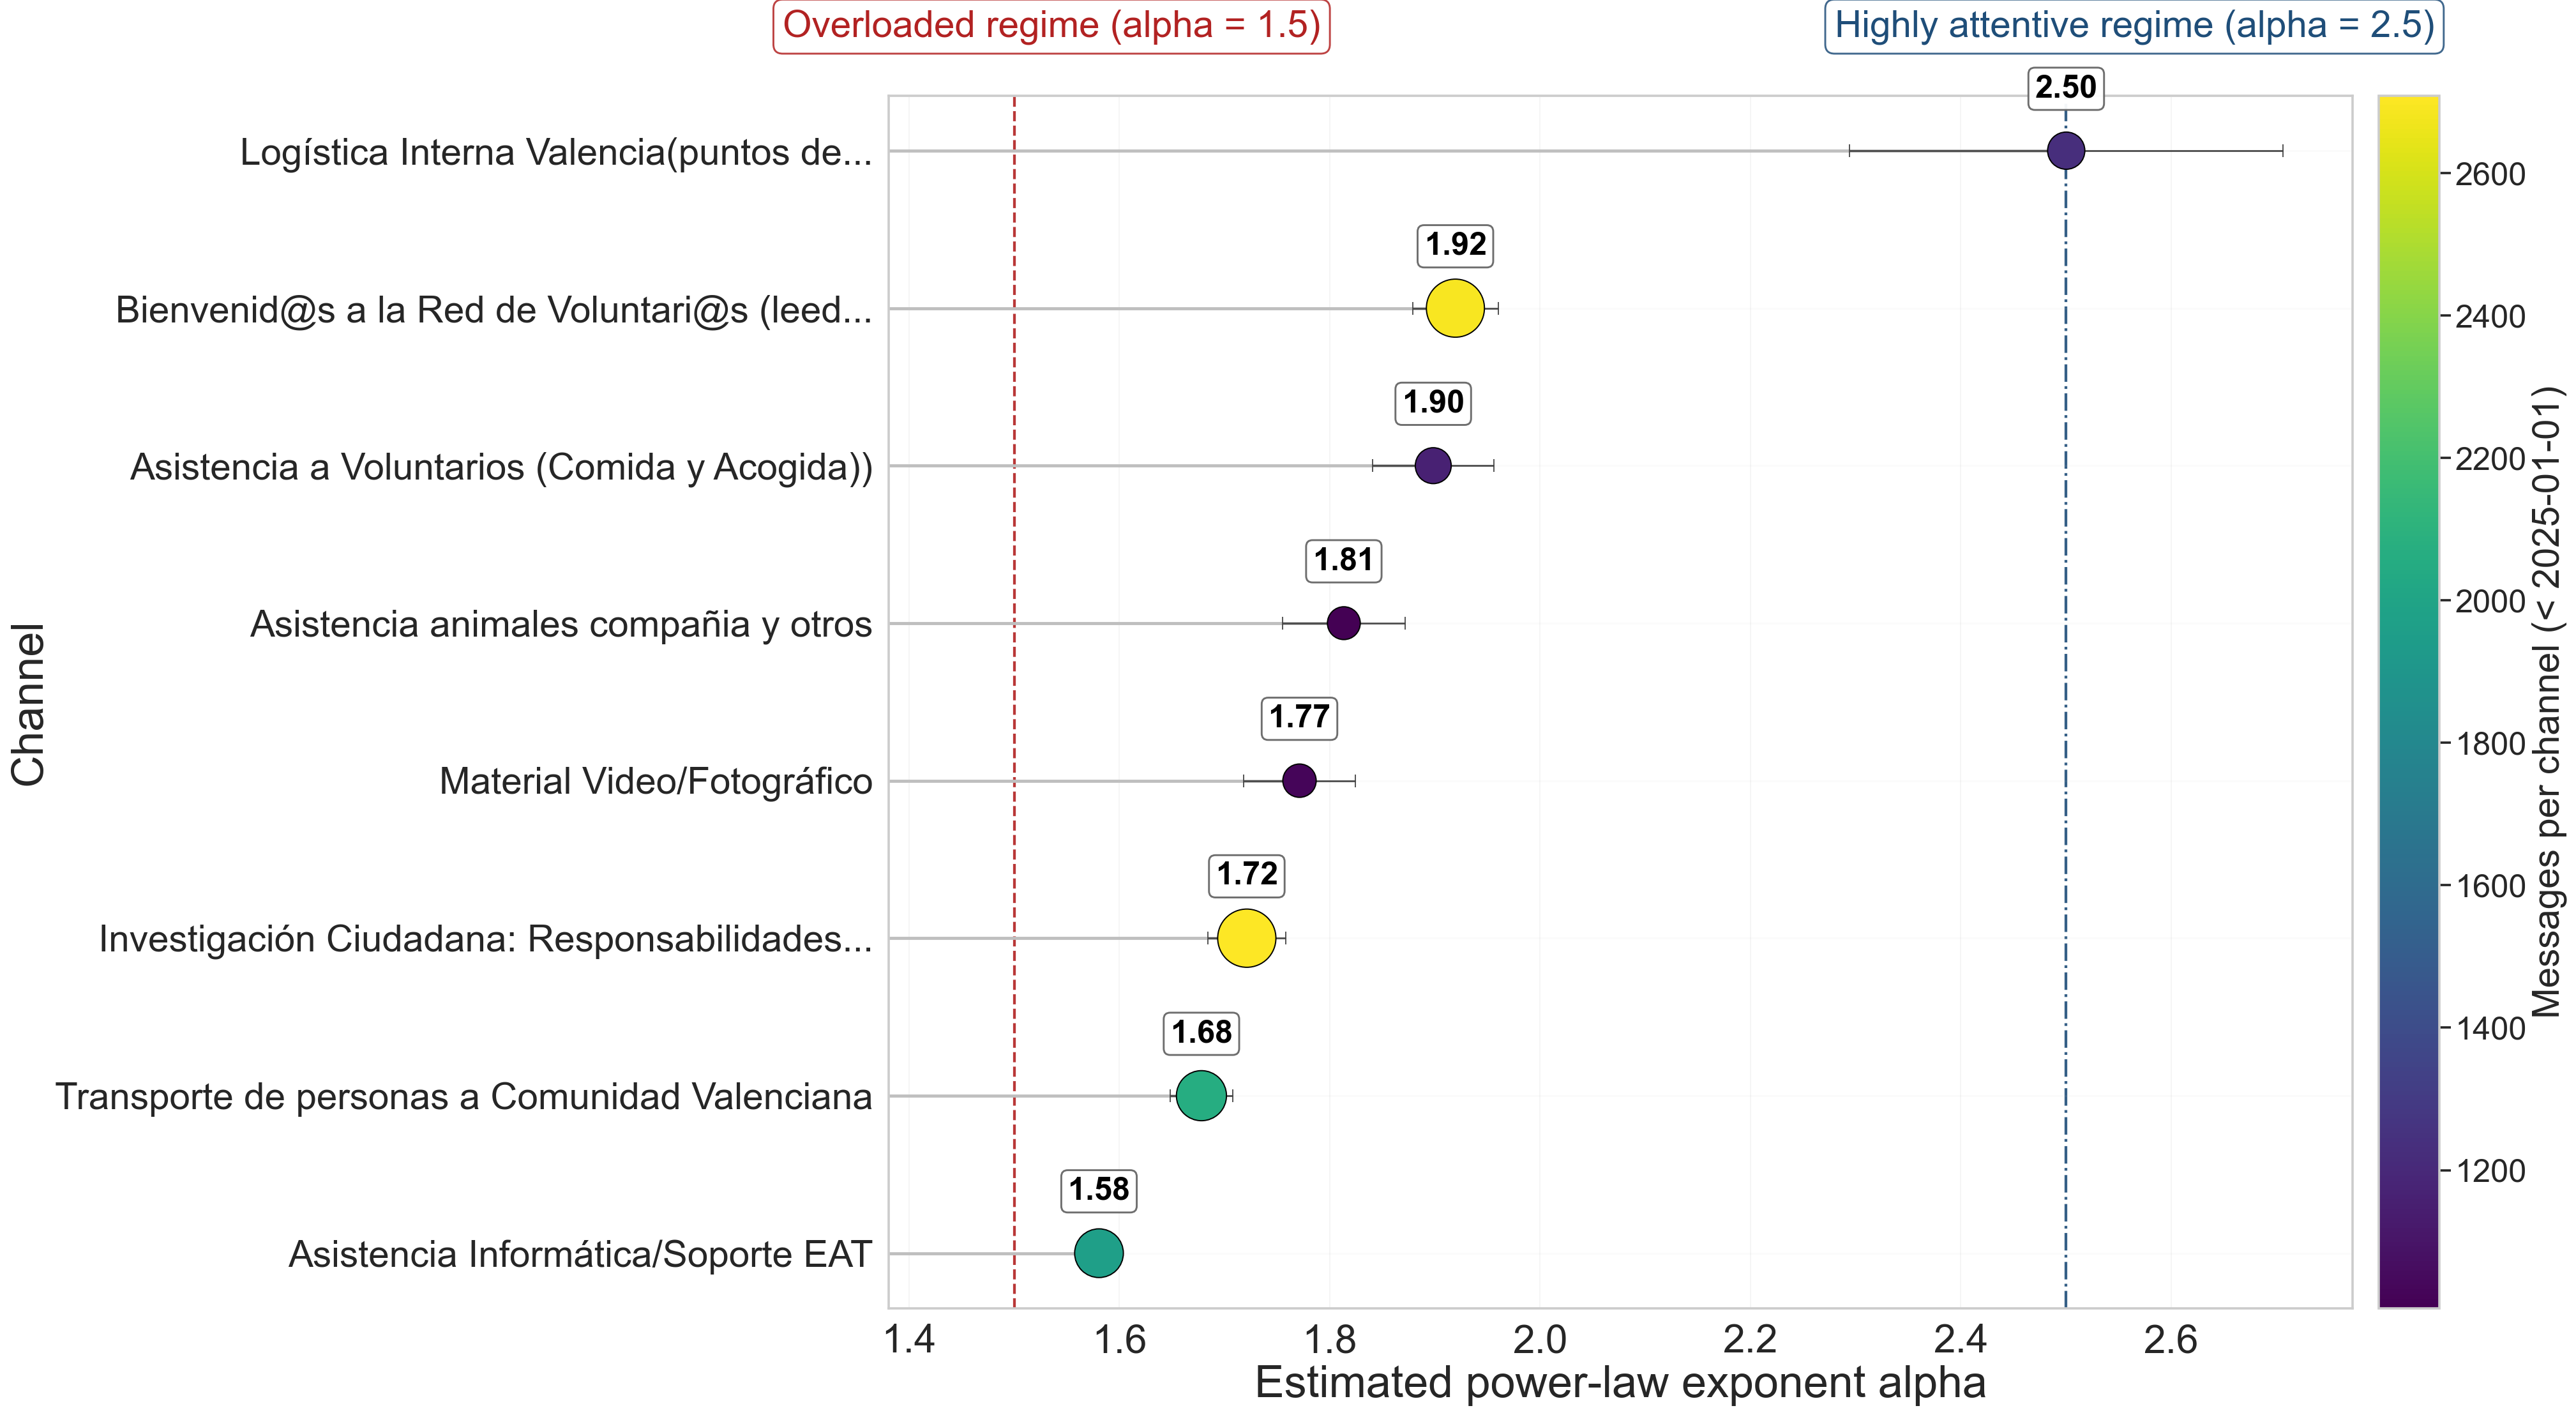

,channel,max_waiting_time_seconds,max_waiting_time_days,n_messages
0,Asistencia a Voluntarios (Comida y Acogida)),1245806.0,14.419051,1163
1,Bienvenid@s a la Red de Voluntari@s (leed prim...,999153.0,11.564271,2695
2,Asistencia animales compañia y otros,896493.0,10.376076,1006
3,Asistencia Informática/Soporte EAT,566344.0,6.554907,1960
4,Logística Interna Valencia(puntos de recepción),422845.0,4.894039,1231
5,Investigación Ciudadana: Responsabilidades Pol...,347517.0,4.022188,2709
6,Material Video/Fotográfico,247324.0,2.862546,1030
7,Transporte de personas a Comunidad Valenciana,224614.0,2.599699,2058


<Figure size 896x672 with 0 Axes>

In [ ]:
# Compare power-law exponents (alpha) across channels (>1000 msgs),
# using data only up to 2025-01-01.


# Ensure datetime
df_alpha = df.copy()
df_alpha['date'] = pd.to_datetime(df_alpha['date'], errors='coerce')
df_alpha = df_alpha.dropna(subset=['date', 'topic_name'])



# Truncate dataset on Jan 1st, 2025 (handle tz-aware timestamps safely)
date_tz = df_alpha['date'].dt.tz
cutoff_date = pd.Timestamp('2025-01-01', tz=date_tz) if date_tz is not None else pd.Timestamp('2025-01-01')
df_alpha = df_alpha[df_alpha['date'] < cutoff_date].copy()

# Keep channels with >1000 messages in truncated window
channel_sizes = df_alpha.groupby('topic_name').size().sort_values(ascending=False)
eligible_channels = channel_sizes[channel_sizes > 1000].index

results = []
for channel in eligible_channels:
    ch = df_alpha.loc[df_alpha['topic_name'] == channel, ['date']].sort_values('date').copy()
    waiting = ch['date'].diff().dt.total_seconds().dropna()
    waiting = waiting[(waiting > 0) & np.isfinite(waiting)]

    # Skip channels with too few inter-arrival times for stable fitting
    if len(waiting) < 100:
        continue

    # Subsample large channels for speed while keeping tail structure
    if len(waiting) > 6000:
        waiting = waiting.sample(6000, random_state=42).sort_values()

    try:
        # Power-law alpha from Clauset-style fit (faster and stable for multi-channel comparison)
        fit = powerlaw.Fit(waiting.values, discrete=True, verbose=False)
        pl = fit.power_law

        alpha = float(getattr(pl, 'alpha', np.nan))
        sigma = float(getattr(pl, 'sigma', np.nan))
        xmin = float(getattr(pl, 'xmin', np.nan))
        n_tail = int(np.sum(waiting.values >= xmin)) if np.isfinite(xmin) else np.nan

        if np.isfinite(alpha):
            results.append({
                'channel': channel,
                'alpha': alpha,
                'sigma': sigma if np.isfinite(sigma) else np.nan,
                'xmin': xmin,
                'n_messages': int(channel_sizes[channel]),
                'n_waiting': int(len(waiting)),
                'n_tail': n_tail,
            })
    except Exception as exc:
        print(f"Skipping channel due to fit error: {channel} -> {exc}")

alpha_df = pd.DataFrame(results).sort_values('alpha', ascending=True).reset_index(drop=True)

if alpha_df.empty:
    raise ValueError('No valid alpha estimates could be computed for channels >1000 messages.')

# Short labels for cleaner poster plotting
alpha_df['channel_label'] = alpha_df['channel'].apply(
    lambda s: textwrap.shorten(str(s), width=46, placeholder='...')
)

# --- POSTER-STYLE LARGER FONTS ---
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams.update({
    'figure.dpi': 140,
    'savefig.dpi': 300,
    'axes.titlesize': 42,        # increased
    'axes.labelsize': 36,        # increased
    'xtick.labelsize': 32,       # increased
    'ytick.labelsize': 30,       # increased
})

# Minimal space above plot for annotation text
fig, ax = plt.subplots(figsize=(30, 16))
plt.subplots_adjust(top=0.88, bottom=0.18)  # minimal space above

# Lollipop baseline from minimum alpha
x0 = max(0, alpha_df['alpha'].min() - 0.2)
for i, row in alpha_df.iterrows():
    ax.hlines(
        y=i, xmin=x0, xmax=row['alpha'], color='0.75', linewidth=2.5, zorder=1
    )

# Make dots much bigger
sizes = np.interp(alpha_df['n_messages'], (alpha_df['n_messages'].min(), alpha_df['n_messages'].max()), (700, 2200))

scatter = ax.scatter(
    alpha_df['alpha'],
    np.arange(len(alpha_df)),
    s=sizes,
    c=alpha_df['n_messages'],
    cmap='viridis',
    edgecolor='black',
    linewidth=1.0,
    zorder=3
)

# Uncertainty bars when sigma is available
valid_sigma = alpha_df['sigma'].notna()
ax.errorbar(
    alpha_df.loc[valid_sigma, 'alpha'],
    np.where(valid_sigma)[0],
    xerr=alpha_df.loc[valid_sigma, 'sigma'],
    fmt='none',
    ecolor='0.25',
    elinewidth=1.5,
    capsize=5,
    zorder=2,
    alpha=0.9
)

# Regime reference lines
ax.axvline(1.5, color='#B22222', linestyle='--', linewidth=2.2, alpha=0.9, zorder=0)
ax.axvline(2.5, color='#1F4E79', linestyle='-.', linewidth=2.2, alpha=0.9, zorder=0)

# Place annotation text just above the plot
ax.text(
    1.28, len(alpha_df) - 0.1, 'Overloaded regime (alpha = 1.5)',
    color='#B22222', fontsize=30, va='top', ha='left',
    bbox=dict(facecolor='white', edgecolor='#B22222', alpha=0.85, boxstyle='round,pad=0.25')
)
ax.text(
    2.28, len(alpha_df) - 0.1, 'Highly attentive regime (alpha = 2.5)',
    color='#1F4E79', fontsize=30, va='top', ha='left',
    bbox=dict(facecolor='white', edgecolor='#1F4E79', alpha=0.85, boxstyle='round,pad=0.25')
)

ax.set_yticks(np.arange(len(alpha_df)))
ax.set_yticklabels(alpha_df['channel_label'], fontsize=30)  # ensure ytick labels also big
ax.set_xlabel('Estimated power-law exponent alpha', fontsize=36)
ax.set_ylabel('Channel', fontsize=36)
ax.set_xlim(left=x0)
ax.grid(axis='x', alpha=0.25, linewidth=0.8)
ax.grid(axis='y', alpha=0.08)

# Colorbar with larger font
cbar = plt.colorbar(scatter, ax=ax, pad=0.015)
cbar.set_label('Messages per channel (< 2025-01-01)', fontsize=30)
cbar.ax.tick_params(labelsize=26)

# Place alpha labels above the dots
for i, row in alpha_df.iterrows():
    ax.annotate(
        f"{row['alpha']:.2f}",
        (row['alpha'], i),
        xytext=(0, 38),
        textcoords='offset points',
        va='bottom',
        ha='center',
        fontsize=26,
        color='black',
        fontweight='bold',
        bbox=dict(facecolor='white', edgecolor='0.4', alpha=0.95, boxstyle='round,pad=0.2')
    )

plt.tight_layout()
plt.show()
plt.savefig('alpha_comparison_poster.svg', format='svg', bbox_inches='tight')

# Optional table for reporting
alpha_df[['channel', 'alpha', 'sigma', 'xmin', 'n_messages', 'n_waiting', 'n_tail']]

# Put maximum waiting times for each channel in a table, sorted by max waiting time, to understand which channels have the longest tails in terms of actual waiting times (not just alpha).
max_waiting = []
for channel in eligible_channels:
    ch = df_alpha.loc[df_alpha['topic_name'] == channel, ['date']].sort_values('date').copy()
    waiting = ch['date'].diff().dt.total_seconds().dropna()
    waiting = waiting[(waiting > 0) & np.isfinite(waiting)]
    if len(waiting) > 0:
        max_waiting.append({
            'channel': channel,
            'max_waiting_time_seconds': waiting.max(),
            'max_waiting_time_days': waiting.max() / (3600 * 24),
            'n_messages': int(channel_sizes[channel])
        })
max_waiting_df = pd.DataFrame(max_waiting).sort_values('max_waiting_time_seconds', ascending=False).reset_index(drop=True)
max_waiting_df[['channel', 'max_waiting_time_seconds', 'max_waiting_time_days', 'n_messages']] 

